# Analysis and Detection Plots (Section 7)

Reproduces every Section 7 figure from the results JSONL written by
`experiments/run_experiment.ipynb`, plus the A2 detection-signal scatters. No raw
datasets or prediction JSONs are required: every quantity is read from the run
records.

**Pooled identifiability / utility figures**
1. Centrality vs. quality (rank-rank, pooled).
2. Separation vs. selection quality (pooled).
3. Gap vs. gain (weighted and majority).

**Per-dataset failure-mode figures**
4. IMDb -- centrality vs. F1 (A1, weak separability).
5. CIFAR-10 -- centrality vs. F1 (A1 contrast, strong separability).
6. Santander -- centrality rank vs. F1 rank (A2, inverted geometry).
7. QNLI -- separation vs. expert rank (A3, structural outlier).

**A2 detection-signal scatters**
8. Under-bias vs. separation gap.
9. Over-bias vs. separation gap.

Per-dataset figures select records by the `dataset` field; adjust the dataset
keys below if your prediction files use different names.


In [ ]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict

RESULTS_JSONL = "data/results/experiment_records.jsonl"

records = []
with open(RESULTS_JSONL) as f:
    for line in f:
        records.append(json.loads(line))
print(f"Loaded {len(records)} run records "
      f"across {len({r['dataset'] for r in records})} dataset(s).")

FileNotFoundError: [Errno 2] No such file or directory: 'data/results/experiment_records.jsonl'

## Helpers

Each record stores, per class: `per_model_f1` (model -> F1), `per_model_centrality`
(model -> centrality), `per_class_f1` (method -> F1), `expert_partition`, and the
`signals` (including `separation_gap`). The helpers below turn these into the
per-(dataset, class) rows each figure consumes.

In [ ]:
def mean_expert_rank(per_model_f1_c, experts):
    """Mean F1-rank (1 = best) of the selected experts within a class."""
    if not per_model_f1_c or not experts:
        return np.nan
    s = pd.Series(per_model_f1_c)
    ranks = s.rank(ascending=False)
    vals = [ranks[m] for m in experts if m in ranks.index]
    return float(np.mean(vals)) if vals else np.nan

def expert_nonexpert_gap(per_model_f1_c, experts):
    """Mean expert F1 minus mean non-expert F1 for a class."""
    if not per_model_f1_c or not experts:
        return np.nan
    eset = set(experts)
    exp = [v for m, v in per_model_f1_c.items() if m in eset]
    non = [v for m, v in per_model_f1_c.items() if m not in eset]
    if not exp or not non:
        return np.nan
    return float(np.mean(exp) - np.mean(non))

## Figure 1: Centrality rank vs. F1 rank

For each (dataset, class, model) we have a centrality score and a class-conditional
F1. Within each (dataset, class) we rank models by both and scatter the ranks
(lower = more central / better). A positive association means geometry tracks
quality.

Points: 0


KeyError: 'mean_class_centrality_rank'

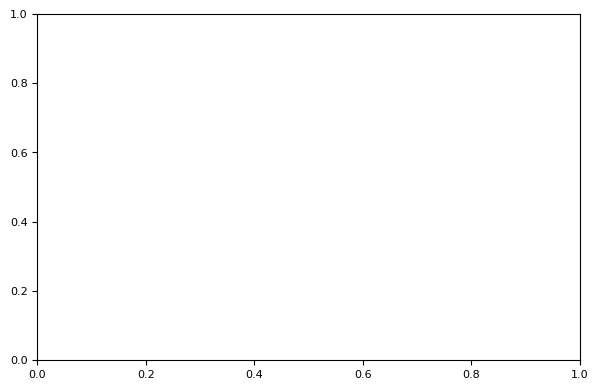

In [ ]:
from collections import defaultdict

# 1) aggregate per (dataset, class, model): average metric across the 60 trials
cent_acc = defaultdict(lambda: defaultdict(lambda: defaultdict(list)))  # ds -> class -> model -> [vals]
f1_acc   = defaultdict(lambda: defaultdict(lambda: defaultdict(list)))
for r in records:
    ds = r["dataset"]
    cmap, fmap = r["per_model_centrality"], r["per_model_f1"]
    for c_str in cmap:
        for m, v in cmap[c_str].items():
            cent_acc[ds][c_str][m].append(v)
        for m, v in fmap.get(c_str, {}).items():
            f1_acc[ds][c_str][m].append(v)

# 2) per dataset: rank within class across models, then average ranks across classes
rows = []
for ds in cent_acc:
    classes = sorted(cent_acc[ds].keys())
    models  = sorted({m for c in cent_acc[ds] for m in cent_acc[ds][c]})
    cent_ranks, f1_ranks = {}, {}
    for c_str in classes:
        cm = {m: float(np.mean(cent_acc[ds][c_str][m])) for m in cent_acc[ds][c_str]}
        fm = {m: float(np.mean(f1_acc[ds].get(c_str, {}).get(m, np.nan)))
              for m in f1_acc[ds].get(c_str, {})}
        common = [m for m in models if m in cm and m in fm]
        if len(common) < 2:
            continue
        cr = pd.Series({m: cm[m] for m in common}).rank(ascending=False)  # 1 = most central
        fr = pd.Series({m: fm[m] for m in common}).rank(ascending=False)  # 1 = best F1
        for m in common:
            cent_ranks.setdefault(m, []).append(cr[m])
            f1_ranks.setdefault(m, []).append(fr[m])
    for m in cent_ranks:
        rows.append({
            "dataset": ds,
            "model": m,
            "mean_class_centrality_rank": float(np.mean(cent_ranks[m])),
            "mean_class_f1_rank": float(np.mean(f1_ranks[m])),
        })

df1 = pd.DataFrame(rows)
print("Points:", len(df1), "| datasets:", df1["dataset"].nunique())

# ---- paper styling (original 7.0 x 4.5 ratio, no title) ----
plt.rcParams.update({
    "font.size": 9, "axes.titlesize": 10, "axes.labelsize": 9,
    "xtick.labelsize": 8, "ytick.labelsize": 8, "legend.fontsize": 8,
    "axes.linewidth": 0.8, "pdf.fonttype": 42, "ps.fonttype": 42,
})

fig, ax = plt.subplots(figsize=(7.0, 4.5))
ax.scatter(df1["mean_class_centrality_rank"], df1["mean_class_f1_rank"],
           s=18, alpha=0.6, linewidths=0.0, color="tab:blue")
ax.invert_xaxis()
ax.invert_yaxis()
ax.set_xlabel("Centrality rank")
ax.set_ylabel("F1 rank")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(True, alpha=0.18, linewidth=0.6)
fig.tight_layout()

fig.savefig("fig7_1a_centrality_vs_f1_rank.pdf", bbox_inches="tight")
plt.show()

## Figure 2: Separation gap vs. mean expert rank

Per (dataset, class), the x-axis is the selected subset's separation gap (from the
record's signals), and the y-axis is the mean F1-rank of the selected experts
(lower = the method picked stronger models). Moderate separation should coincide
with low (good) expert rank; very low or very high separation with worse rank.

In [ ]:
# ---- data (unchanged: same sep_gap / mean_expert_rank, collapsed to (dataset, class)) ----
rows = []
for r in records:
    for c_str, sig in r["signals"].items():
        experts = r["expert_partition"].get(c_str, [])
        pmf1 = r["per_model_f1"].get(c_str, {})
        sep = sig.get("separation_gap")
        rank = mean_expert_rank(pmf1, experts)
        if sep is None or not np.isfinite(sep) or not np.isfinite(rank):
            continue
        rows.append({"dataset": r["dataset"], "class": c_str,
                     "sep_gap": sep, "mean_expert_rank": rank})

df2 = pd.DataFrame(rows).groupby(["dataset", "class"]).mean(numeric_only=True).reset_index()

# ---- trend view (paper version, journal-ready) ----
N_BINS        = 20
TRIM_PCT      = 100.0   # right tail (visual only)
TRIM_LEFT_PCT = 1.0     # left tail (visual only)

plt.rcParams.update({
    "font.size": 9, "axes.titlesize": 10, "axes.labelsize": 9,
    "xtick.labelsize": 8, "ytick.labelsize": 8, "legend.fontsize": 8,
    "axes.linewidth": 0.8, "pdf.fonttype": 42, "ps.fonttype": 42,
})

x = df2["sep_gap"].values
y = df2["mean_expert_rank"].values

x_f   = x[np.isfinite(x)]
x_min = np.percentile(x_f, TRIM_LEFT_PCT)
x_max = np.percentile(x_f, TRIM_PCT)
mask  = np.isfinite(x) & np.isfinite(y) & (x >= x_min) & (x <= x_max)
x_t, y_t = x[mask], y[mask]

bins    = np.linspace(x_t.min(), x_t.max(), N_BINS + 1)
bin_ids = np.digitize(x_t, bins) - 1
brows = []
for b in range(N_BINS):
    m = bin_ids == b
    if not np.any(m):
        continue
    brows.append({"x_center": x_t[m].mean(),
                  "y_mean": y_t[m].mean(),
                  "y_std": y_t[m].std(ddof=0)})
df_bins = pd.DataFrame(brows)

LINE_COLOR = "#2F4B7C"
fig, ax = plt.subplots(figsize=(7.0, 4.5))
ax.scatter(x_t, y_t, s=18, alpha=0.30, color="#4C72B0", zorder=1)
ax.plot(df_bins["x_center"], df_bins["y_mean"], linewidth=2.4, marker="o",
        markersize=4, color=LINE_COLOR, zorder=3, label="Binned mean")
ax.fill_between(df_bins["x_center"],
                df_bins["y_mean"] - df_bins["y_std"],
                df_bins["y_mean"] + df_bins["y_std"],
                color=LINE_COLOR, alpha=0.18, linewidth=0, zorder=2)

ax.set_xlabel(r"$\overline{d}_{\mathrm{inter}} - \overline{d}_{\mathrm{intra}}$")
ax.set_ylabel("Mean selected rank")
ax.set_xlim(x_min, x_max)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(True, alpha=0.18, linewidth=0.6)
ax.legend(frameon=False)
fig.tight_layout()

fig.savefig("fig7_2_separation_vs_selection.pdf", bbox_inches="tight")
plt.show()
print(f"{len(df2)} (dataset, class) points; plotted {mask.sum()} after trim.")

## Figure 3: Expert-nonexpert gap vs. ensemble gain

Per (dataset, class): x is the expert-nonexpert F1 gap; y is the gain from
restriction. Left panel uses weighted aggregation
(`experts_weighted - all_weighted`), right panel majority
(`experts_majority - all_majority`). Gain should rise with the gap.

In [ ]:
# ---- data (unchanged: gap + weighted/majority gains, collapsed to (dataset, class)) ----
rows = []
for r in records:
    pcf1 = r["per_class_f1"]
    for c_str in r["per_model_f1"]:
        experts = r["expert_partition"].get(c_str, [])
        gap = expert_nonexpert_gap(r["per_model_f1"][c_str], experts)
        if not np.isfinite(gap):
            continue
        c = c_str
        gw = pcf1["experts_weighted"].get(c, np.nan) - pcf1["all_weighted"].get(c, np.nan)
        gm = pcf1["experts_majority"].get(c, np.nan) - pcf1["all_majority"].get(c, np.nan)
        rows.append({"dataset": r["dataset"], "class": c_str, "gap": gap,
                     "gain_weighted": gw, "gain_majority": gm})

df3 = (pd.DataFrame(rows).groupby(["dataset", "class"]).mean(numeric_only=True).reset_index())

# ---- trend view (paper version, journal-ready) ----
SCATTER_COLOR = "#4C72B0"
LINE_COLOR    = "#2F4B7C"

plt.rcParams.update({
    "font.size": 9, "axes.titlesize": 10, "axes.labelsize": 9,
    "xtick.labelsize": 8, "ytick.labelsize": 8, "legend.fontsize": 8,
    "axes.linewidth": 0.8, "pdf.fonttype": 42, "ps.fonttype": 42,
})

def _finite(a):
    a = np.asarray(a, dtype=float)
    return a[np.isfinite(a)]

def _safe_quantile(a, qs, fallback=None):
    a = _finite(a)
    if a.size == 0:
        return fallback
    return np.nanquantile(a, qs)

def _moving_average(y, win=5):
    y = np.asarray(y, dtype=float)
    if win <= 1 or y.size < 3:
        return y
    win = int(win)
    if win % 2 == 0:
        win += 1
    pad = win // 2
    ypad = np.pad(y, (pad, pad), mode="edge")
    kernel = np.ones(win, dtype=float) / win
    return np.convolve(ypad, kernel, mode="valid")

def _count_bins(x, y, n_bins=30, x_trim=(0.011, 0.989), use_median_x=True):
    x = np.asarray(x, dtype=float); y = np.asarray(y, dtype=float)
    m = np.isfinite(x) & np.isfinite(y)
    x, y = x[m], y[m]
    if x.size == 0:
        return pd.DataFrame(columns=["x_center", "y_mean", "y_std", "n"])
    q = _safe_quantile(x, list(x_trim))
    if q is None:
        return pd.DataFrame(columns=["x_center", "y_mean", "y_std", "n"])
    lo, hi = q
    if not np.isfinite(lo) or not np.isfinite(hi) or lo >= hi:
        return pd.DataFrame(columns=["x_center", "y_mean", "y_std", "n"])
    keep = (x >= lo) & (x <= hi)
    x_t, y_t = x[keep], y[keep]
    if x_t.size == 0:
        return pd.DataFrame(columns=["x_center", "y_mean", "y_std", "n"])
    edges = np.unique(np.quantile(x_t, np.linspace(0.0, 1.0, int(n_bins) + 1)))
    if edges.size < 3:
        return pd.DataFrame(columns=["x_center", "y_mean", "y_std", "n"])
    brows = []
    for a, b in zip(edges[:-1], edges[1:]):
        if a == b:
            continue
        sel = (x_t >= a) & (x_t <= b) if b == edges[-1] else ((x_t >= a) & (x_t < b))
        n = int(sel.sum())
        if n == 0:
            continue
        xb, yb = x_t[sel], y_t[sel]
        brows.append({"x_center": float(np.nanmedian(xb) if use_median_x else np.nanmean(xb)),
                      "y_mean": float(np.nanmean(yb)),
                      "y_std": float(np.nanstd(yb, ddof=0)), "n": n})
    return pd.DataFrame(brows).sort_values("x_center").reset_index(drop=True)

def _plot_binned_smoothed(ax, df_bins, smooth_win=9):
    if df_bins is None or len(df_bins) == 0:
        return
    xb = df_bins["x_center"].to_numpy()
    ym = df_bins["y_mean"].to_numpy()
    ys = df_bins["y_std"].to_numpy()
    ym_s = _moving_average(ym, win=smooth_win)
    ax.plot(xb, ym_s, linewidth=2.4, color=LINE_COLOR, zorder=3)
    ax.fill_between(xb, ym_s - ys, ym_s + ys, color=LINE_COLOR, alpha=0.18, linewidth=0, zorder=2)

def _style_axis(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(True, alpha=0.18, linewidth=0.6)

# ---- Controls ----
N_BINS     = 32
SMOOTH_WIN = 9
X_TRIM     = (0.012, 0.98)
Y_TRIM     = (0.01, 0.995)

x   = df3["gap"].to_numpy(dtype=float)
y_w = df3["gain_weighted"].to_numpy(dtype=float)
y_m = df3["gain_majority"].to_numpy(dtype=float)

qx = _safe_quantile(x, list(X_TRIM),
                    fallback=[np.nanmin(_finite(x)) if _finite(x).size else -1.0,
                              np.nanmax(_finite(x)) if _finite(x).size else 1.0])
x_lo, x_hi = qx
if not np.isfinite(x_lo) or not np.isfinite(x_hi) or x_lo >= x_hi:
    xf = _finite(x)
    x_lo, x_hi = (float(np.min(xf)), float(np.max(xf))) if xf.size else (-1.0, 1.0)

y_all = np.concatenate([_finite(y_w), _finite(y_m)])
qy = _safe_quantile(y_all, list(Y_TRIM), fallback=[-0.05, 0.05])
y_lo, y_hi = qy
y_lim = float(max(abs(y_lo), abs(y_hi), 0.05))

bins_w = _count_bins(x, y_w, n_bins=N_BINS, x_trim=X_TRIM)
bins_m = _count_bins(x, y_m, n_bins=N_BINS, x_trim=X_TRIM)

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True, sharey=True)

ax = axes[0]
ax.scatter(x, y_w, s=18, alpha=0.30, color=SCATTER_COLOR, zorder=1)
ax.axhline(0, linewidth=1, color=SCATTER_COLOR, alpha=0.75, zorder=0)
_plot_binned_smoothed(ax, bins_w, smooth_win=SMOOTH_WIN)
ax.set_xlabel(r"Expert$-$nonexpert gap")
ax.set_ylabel("Ensemble gain")
ax.set_xlim(x_lo, x_hi); ax.set_ylim(-y_lim, y_lim)
ax.text(0.02, 0.97, "(a)", transform=ax.transAxes, va="top", ha="left", fontsize=9)
_style_axis(ax)

ax = axes[1]
ax.scatter(x, y_m, s=18, alpha=0.30, color=SCATTER_COLOR, zorder=1)
ax.axhline(0, linewidth=1, color=SCATTER_COLOR, alpha=0.75, zorder=0)
_plot_binned_smoothed(ax, bins_m, smooth_win=SMOOTH_WIN)
ax.set_xlabel(r"Expert$-$nonexpert gap")
ax.set_xlim(x_lo, x_hi); ax.set_ylim(-y_lim, y_lim)
ax.text(0.02, 0.97, "(b)", transform=ax.transAxes, va="top", ha="left", fontsize=9)
_style_axis(ax)

fig.tight_layout()
fig.savefig("fig7_3_gap_vs_ensemble_gain.pdf", bbox_inches="tight")
plt.show()
print(f"{len(df3)} (dataset, class) points; plotted within trim window.")

## Per-dataset failure-mode figures

The following figures reproduce the specific datasets used as failure-mode
examples in Section~7.3. They read the same per-model centrality and F1 stored in
the records, filtered to one dataset. Set the dataset keys to match your files.

In [ ]:
# Dataset keys as they appear in the records / failure_mode_points.json
DS_IMDB      = "IMDB"
DS_CIFAR10   = "CIFAR10"
DS_SANTANDER = "Santander_Customer_Transaction_Prediction"
DS_QNLI      = "QNLI"

plt.rcParams.update({
    "font.size": 9, "axes.titlesize": 10, "axes.labelsize": 9,
    "xtick.labelsize": 8, "ytick.labelsize": 8, "legend.fontsize": 8,
    "axes.linewidth": 0.8, "pdf.fonttype": 42, "ps.fonttype": 42,
})

# Precomputed per-(model,class) centrality + F1 (doc-6 predicted-set metric),
# built once by experiments/make_failure_mode_points. The notebook reads only
# this small JSON, so no predictions are needed here.
import json as _json
with open("data/results/failure_mode_points.json") as _f:
    FAILURE_POINTS = _json.load(_f)

def failure_points(dataset):
    pts = FAILURE_POINTS.get(dataset, [])
    x   = np.array([p["centrality"] for p in pts])
    y   = np.array([p["f1"] for p in pts])
    cls = np.array([p["class"] for p in pts])
    return x, y, cls

### Figure 4: IMDb centrality vs. F1 (A1 -- weak separability)

Models occupy a narrow centrality band, so near-identical centrality coincides
with meaningfully different F1: weak effective separability.

In [ ]:
x, y, cls = failure_points(DS_IMDB)
fig, ax = plt.subplots(figsize=(6.2, 4.2))
for c in sorted(set(cls.tolist())):
    m = cls == c
    ax.scatter(x[m], y[m], s=18, alpha=0.65, linewidths=0.0, label=f"class {c}")
ax.set_xlabel("Centrality")
ax.set_ylabel("F1")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(True, alpha=0.18, linewidth=0.6)
if len(set(cls.tolist())) <= 12:
    ax.legend(frameon=False)
fig.tight_layout()
fig.savefig("fig7_4_imdb_centrality_vs_f1.pdf", bbox_inches="tight")
plt.show()
print(f"{len(x)} (model, class) points for {DS_IMDB}")

### Figure 5: CIFAR-10 centrality vs. F1 (A1 contrast)

Centrality spans a wide range and cleanly separates strong from weak models -- the
high signal-to-noise contrast to IMDb.

In [ ]:
x, y, cls = failure_points(DS_CIFAR10)
fig, ax = plt.subplots(figsize=(6.2, 4.2))
for c in sorted(set(cls.tolist())):
    m = cls == c
    ax.scatter(x[m], y[m], s=18, alpha=0.65, linewidths=0.0, label=f"class {c}")
ax.set_xlabel("Centrality")
ax.set_ylabel("F1")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(True, alpha=0.18, linewidth=0.6)
if len(set(cls.tolist())) <= 12:
    ax.legend(frameon=False)
fig.tight_layout()
fig.savefig("fig7_5_cifar10_centrality_vs_f1.pdf", bbox_inches="tight")
plt.show()
print(f"{len(x)} (model, class) points for {DS_CIFAR10}")

### Figure 6: Santander centrality rank vs. F1 rank (A2 -- inverted geometry)

Unlike the raw-value plots above, this uses **ranks** within each class. For the
minority class the relationship inverts: the most central models are among the
weakest, the signature of a stable but misaligned expert subset.

In [ ]:
x, y, cls = failure_points(DS_SANTANDER)   # centrality, f1, class (from JSON, one blob)
fig, ax = plt.subplots(figsize=(6.2, 4.2))
for c in sorted(set(cls.tolist())):
    sel = cls == c
    cent_rank = pd.Series(x[sel]).rank(ascending=False).values  # 1 = most central
    f1_rank   = pd.Series(y[sel]).rank(ascending=False).values  # 1 = best
    ax.scatter(cent_rank, f1_rank, s=18, alpha=0.65, linewidths=0.0, label=f"class {c}")
ax.invert_xaxis()
ax.invert_yaxis()
ax.set_xlabel("Centrality rank")
ax.set_ylabel("F1 rank")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(True, alpha=0.18, linewidth=0.6)
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig("fig7_6_santander_rank_vs_rank.pdf", bbox_inches="tight")
plt.show()
print(f"{len(x)} (model, class) points for {DS_SANTANDER}")

### Figure 7: QNLI separation vs. expert rank (A3 -- structural outlier)

QNLI falls within the separation range usually associated with good selection,
yet its selected experts are poor: an outlier relative to the dominant
separation-quality trend, consistent with structural (A3) mismatch.

In [ ]:
# Fig 7 (QNLI, A3): the Fig-2 global trend, with QNLI highlighted.
N_BINS, TRIM_LEFT_PCT, TRIM_PCT = 20, 1.0, 100.0

x = df2["sep_gap"].values
y = df2["mean_expert_rank"].values
x_f   = x[np.isfinite(x)]
x_min = np.percentile(x_f, TRIM_LEFT_PCT)
x_max = np.percentile(x_f, TRIM_PCT)
mask  = np.isfinite(x) & np.isfinite(y) & (x >= x_min) & (x <= x_max)
x_t, y_t = x[mask], y[mask]

bins = np.linspace(x_t.min(), x_t.max(), N_BINS + 1)
bin_ids = np.digitize(x_t, bins) - 1
brows = []
for b in range(N_BINS):
    mb = bin_ids == b
    if not np.any(mb):
        continue
    brows.append({"x_center": x_t[mb].mean(), "y_mean": y_t[mb].mean(), "y_std": y_t[mb].std(ddof=0)})
df_bins = pd.DataFrame(brows)

dh = df2[df2["dataset"] == DS_QNLI]
dh = dh[np.isfinite(dh["sep_gap"]) & np.isfinite(dh["mean_expert_rank"])]
dh = dh[(dh["sep_gap"] >= x_min) & (dh["sep_gap"] <= x_max)]

LINE_COLOR = "#2F4B7C"
fig, ax = plt.subplots(figsize=(7.0, 4.5))
ax.scatter(x_t, y_t, s=18, alpha=0.25, color="#4C72B0", zorder=1)
ax.plot(df_bins["x_center"], df_bins["y_mean"], linewidth=2.4, marker="o",
        markersize=4, color=LINE_COLOR, zorder=2)
ax.fill_between(df_bins["x_center"], df_bins["y_mean"] - df_bins["y_std"],
                df_bins["y_mean"] + df_bins["y_std"], color=LINE_COLOR, alpha=0.18,
                linewidth=0, zorder=1)
ax.scatter(dh["sep_gap"], dh["mean_expert_rank"], s=85, facecolors="none",
           edgecolors="black", linewidths=1.6, label="QNLI", zorder=4)

ax.set_xlabel(r"$\overline{d}_{\mathrm{inter}} - \overline{d}_{\mathrm{intra}}$")
ax.set_ylabel("Mean selected rank")
ax.set_xlim(x_min, x_max)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(True, alpha=0.18, linewidth=0.6)
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig("fig7_7_qnli_separation_highlight.pdf", bbox_inches="tight")
plt.show()
print(f"QNLI highlighted points: {len(dh)} | background points: {mask.sum()}")

## A2 detection-signal scatters

The two figures from Section~7.4: each class's bias signal (x) against its
separation gap (y), colored by the mean F1-rank of the selected experts (lower =
better). Strong separation together with pronounced bias coincides with degraded
expert quality -- the A2 signature.

In [ ]:
def collect_bias_points(bias_key):
    xs, ys, cs = [], [], []
    for r in records:
        for c_str, sig in r["signals"].items():
            b = sig.get(bias_key)
            sep = sig.get("separation_gap")
            rank = mean_expert_rank(r["per_model_f1"].get(c_str, {}),
                                    r["expert_partition"].get(c_str, []))
            if b is None or sep is None: continue
            if not (np.isfinite(b) and np.isfinite(sep) and np.isfinite(rank)): continue
            xs.append(b); ys.append(sep); cs.append(rank)
    return np.array(xs), np.array(ys), np.array(cs)

plt.rcParams.update({
    "font.size": 9, "axes.titlesize": 10, "axes.labelsize": 9,
    "xtick.labelsize": 8, "ytick.labelsize": 8, "legend.fontsize": 8,
    "axes.linewidth": 0.8, "pdf.fonttype": 42, "ps.fonttype": 42,
})

TH_SEP_GAP = 0.535
CLIP = 10.0
PANELS = [
    ("under_bias", 0.8, "Under-bias signal", "fig8_underbias_vs_separation.pdf"),
    ("over_bias",  2.0, "Over-bias signal",  "fig9_overbias_vs_separation.pdf"),
]

# shared color scale across both figures
data = {key: collect_bias_points(key) for key, _, _, _ in PANELS}
allc = np.concatenate([d[2] for d in data.values() if len(d[2])])
vmin, vmax = float(np.nanmin(allc)), float(np.nanmax(allc))

for key, th_bias, xlabel, fname in PANELS:
    x, y, c = data[key]
    fig, ax = plt.subplots(figsize=(6.2, 4.4))
    xc = np.clip(x, -CLIP, CLIP)
    sc = ax.scatter(xc, y, c=c, s=18, alpha=0.6, cmap="viridis", vmin=vmin, vmax=vmax)
    cb = fig.colorbar(sc, ax=ax)
    cb.set_label("Mean expert rank")
    ax.axvline(th_bias, linestyle="--", linewidth=1, color="tab:blue")
    ax.axhline(TH_SEP_GAP, linestyle="--", linewidth=1, color="tab:blue")
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Separation gap")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(True, alpha=0.18, linewidth=0.6)
    fig.tight_layout()
    fig.savefig(fname, bbox_inches="tight")
    plt.show()
    print(f"{key}: {len(x)} points")